# Binary Classification: Detecting the Number '1'

In this notebook, we will use the **DIY Neural Net** library to solve a binary classification problem. 
We will train a model to distinguish between images of the digit '1' and all other digits from a balanced subset of the MNIST dataset.

In [1]:
# Standard Imports
import matplotlib.pyplot as plt

# DIY Library Imports
from diy_neural_net import NeuralNetwork, utils
from diy_neural_net.Layers import Dense, BatchNorm
from diy_neural_net.Activations import ReLU, Sigmoid
from diy_neural_net.Losses import BCELoss
from diy_neural_net.Optimizer import Adam
from diy_neural_net.DeviceSelector import get_numpy, is_gpu_available

np = get_numpy()
print(f"Hardware Acceleration: {'GPU (CuPy)' if is_gpu_available() else 'CPU (NumPy)'}")

Using GPU
Hardware Acceleration: GPU (CuPy)


## 1. Load and Prepare Data
We use the helper function `load_binary_mnist` which provides a pre-balanced dataset.

In [2]:
# Load Data
X, y = utils.load_binary_mnist()

# Split into Train (80%) and Test (20%)
X_train, X_test, y_train, y_test = utils.train_test_split(X, y, test_size=0.2)

print(f"Training Shape: {X_train.shape}")
print(f"Testing Shape: {X_test.shape}")
print(f"Input Features: {X_train.shape[0]} (28x28 pixels)")

Loading data from: ../Data/balanced_mnist_1.csv
Training Shape: (784, 7494)
Testing Shape: (784, 1873)
Input Features: 784 (28x28 pixels)


## 2. Define Network Architecture
We will build a simple feed-forward network:
1. **Input**: 784 pixels
2. **Hidden Layer 1**: 64 neurons + ReLU
3. **Hidden Layer 2**: 32 neurons + ReLU
4. **Output Layer**: 1 neuron + Sigmoid (Probability of being a '1')

In [3]:
n_features = X_train.shape[0]

model = NeuralNetwork.Sequential(
    [
        Dense(input_size=n_features, output_size=64, initializer="he"),
        BatchNorm(64),
        ReLU(),
        Dense(input_size=64, output_size=32, initializer="he"),
        BatchNorm(32),
        ReLU(),
        Dense(input_size=32, output_size=1, initializer="glorot"),
        Sigmoid(),  # Squashes output between 0 and 1
    ]
)

# Set Loss Function
model.set_loss(BCELoss())

## 3. Train the Model
We use the **Adam** optimizer for fast convergence.

In [4]:
optimizer = Adam(model, lr=0.001)

history = model.fit(
    X_train=X_train,
    y_train=y_train,
    optimizer=optimizer,
    epochs=20,
    batch_size=64,
    validation_data=(X_test, y_test),
    early_stopping_patience=3,
)
print(
    f"\nTime Elapsed : {history['Time_Elapsed']:.2F} seconds on : {'GPU' if is_gpu_available() else 'CPU'}\n"
)

Epoch : 0
Train Loss : 0.1812 Test Loss : 0.1075
Early stopping triggered during epoch : 10
best val_loss = 0.0861

Time Elapsed : 1.99 seconds on : GPU



## 4. Evaluation and Visualization

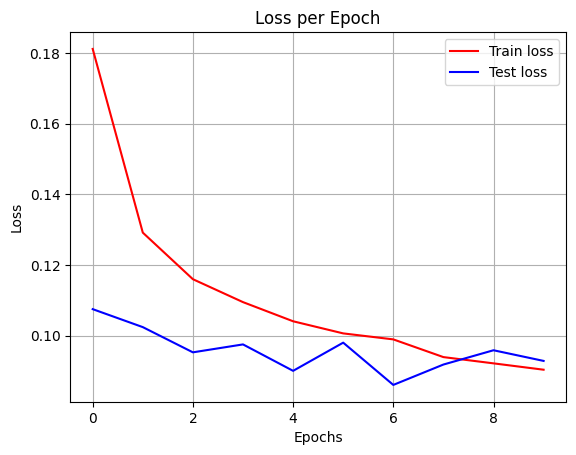

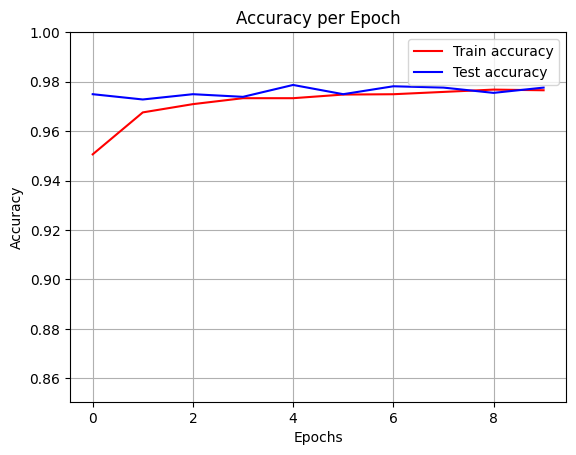

Final Test Accuracy: 97.76%


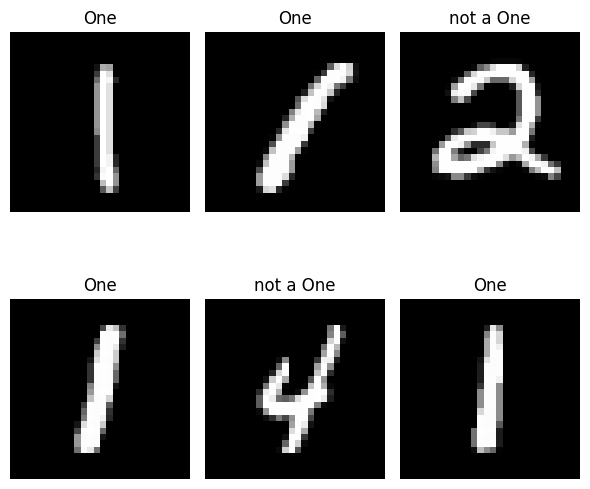

In [5]:
# Plot Loss and Accuracy curves
utils.plot_metrics(history)

# Evaluate final accuracy
preds = model.predict(X_test)
acc = model.accuracy_score(preds, y_test)
print(f"Final Test Accuracy: {acc * 100:.2f}%")

# Visualize some predictions
utils.plot_image(X_test, model, n_images=6, n_classes=1)